# Build end to end Supervised ML pipeline using KNN,Logistic Regression,Navie Bayes,to predict Loan Approved

Implemented Binary Classificationa long with EDA,Feature Engineering & Model Evalution(precision,recall,F1)

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# handle missing values

In [4]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [5]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])


cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [6]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [7]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA -- Explloratory data analysis

Text(0.5, 1.0, ' Is loan approved')

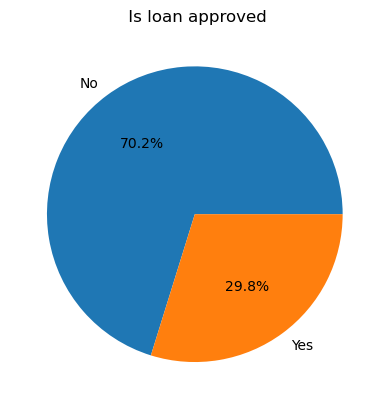

In [8]:
# How balance our classes are?
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels = ["No","Yes"],autopct = "%1.1f%%")
plt.title(" Is loan approved")

[Text(0, 0, '621'), Text(0, 0, '379')]

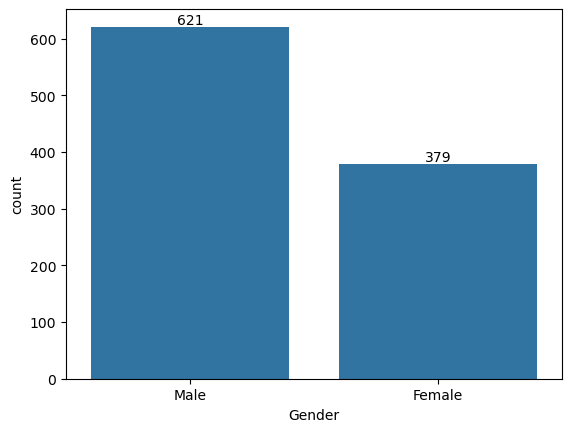

In [9]:
#Analzie categories
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

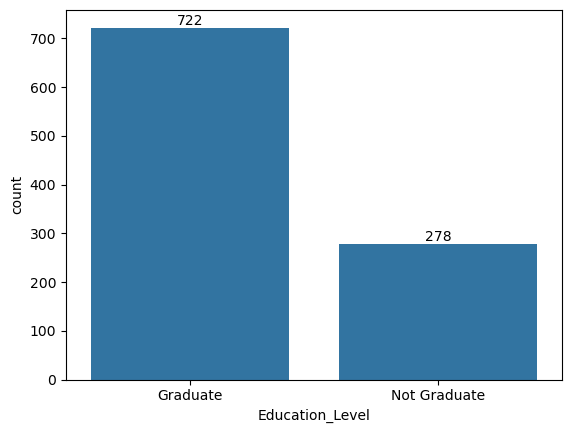

In [10]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

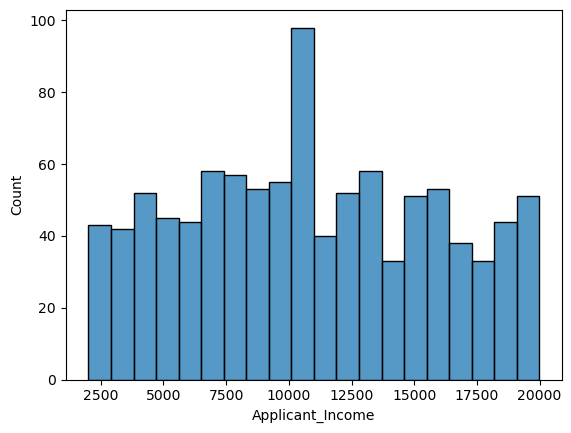

In [11]:
# analize income
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

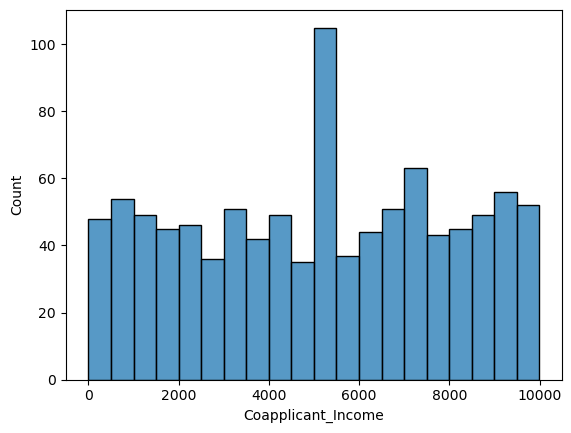

In [12]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

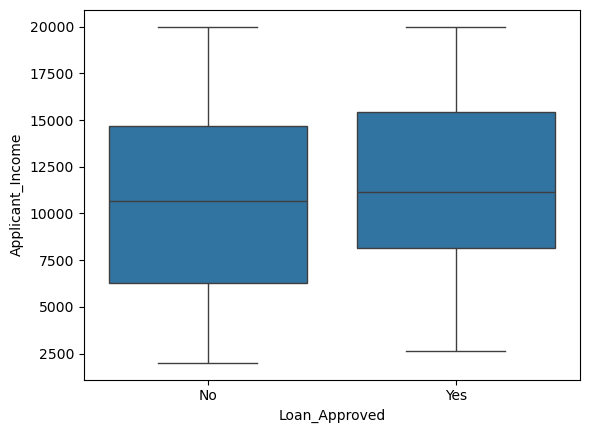

In [13]:
# Outlier --> Boxplot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)


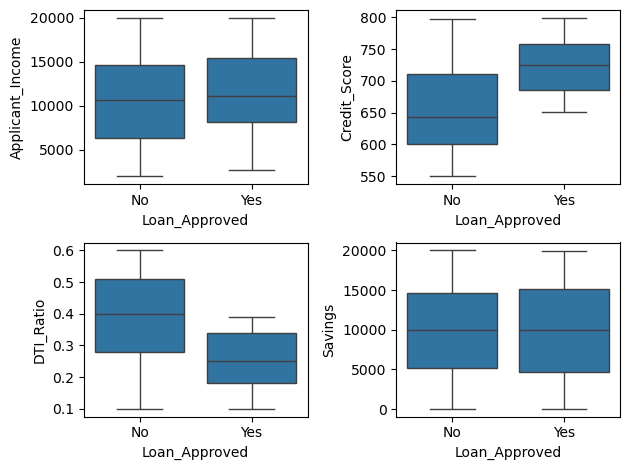

In [14]:
fig,axes = plt.subplots(2, 2)

sns.boxplot(ax = axes[0,0], data = df, x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df, x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = df, x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = df, x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Loan_Approved', ylabel='Age'>

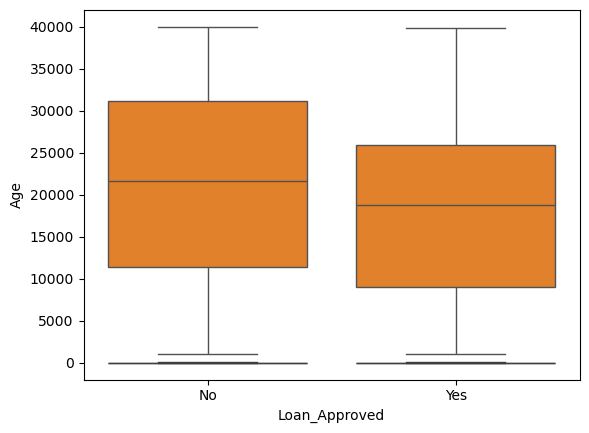

In [15]:
sns.boxplot( data = df, x = "Loan_Approved",y = "Age")
sns.boxplot( data = df, x = "Loan_Approved",y = "Loan_Amount")

<Axes: xlabel='Credit_Score', ylabel='Count'>

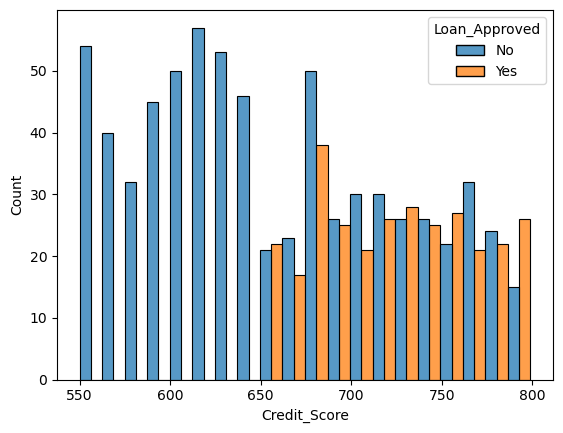

In [16]:
# loan approved with credit score
sns.histplot(
    data = df,
    hue = "Loan_Approved",
    x = "Credit_Score",
    bins = 20,
    multiple = "dodge"
)

In [17]:
# Remove applicant Id
df = df.drop("Applicant_ID",axis=1)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

# Feature Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [20]:
cols = ["Employment_Status","Marital_Status","Gender","Property_Area","Loan_Purpose","Employer_Category"]

ohe  = OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols),index = df.index)
df =pd.concat([df.drop(columns = cols),encoded_df],axis = 1)

In [21]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

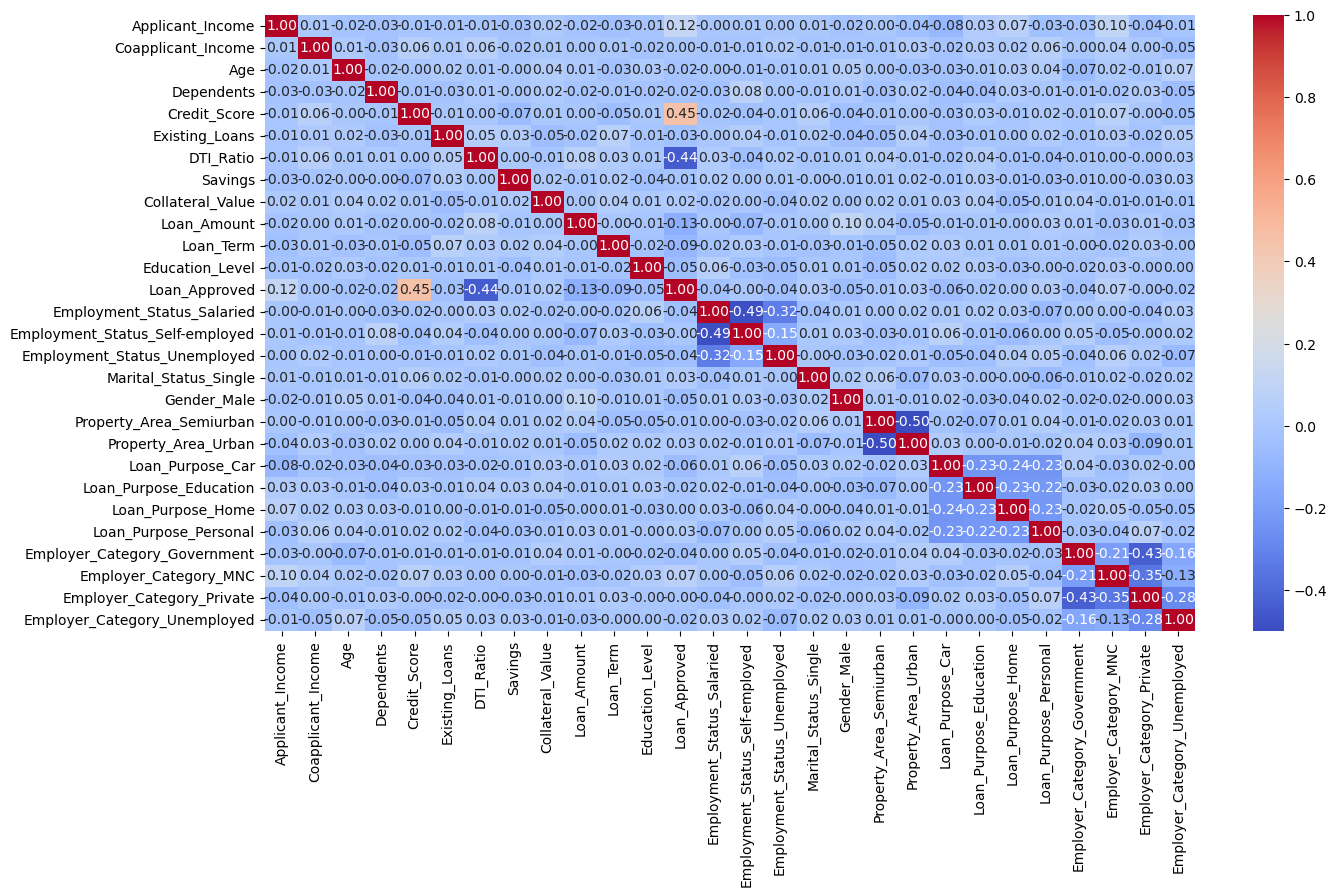

In [33]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()  # here we use correlation to find the relation 

plt.figure(figsize = (15,8))
sns.heatmap(                       #when we make heatmap of relation then it is call correlation heatmap
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [29]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-Test-Split and Featur Scaling

In [34]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [35]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [41]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]])

# Train & Evalute Model

In [55]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score


log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

#Evalution
print("Logistic Regression Model")
print("Precision: ",precision_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("confussion: ",confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision:  0.7833333333333333
accuracy:  0.865
recall_score:  0.7704918032786885
f1_score:  0.7768595041322314
confussion:  [[126  13]
 [ 14  47]]


In [59]:
# KNN regression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score


KNN_model =KNeighborsClassifier(n_neighbors = 5)
KNN_model.fit(X_train_scaled,y_train)

y_pred = KNN_model.predict(X_test_scaled)

#Evalution
print("KNN KNeighborsClassifier Model")
print("Precision: ",precision_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("confussion: ",confusion_matrix(y_test,y_pred))

KNN KNeighborsClassifier Model
Precision:  0.6274509803921569
accuracy:  0.76
recall_score:  0.5245901639344263
f1_score:  0.5714285714285714
confussion:  [[120  19]
 [ 29  32]]


In [65]:
# Naive bayes regression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score


nb_model =GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evalution
print("navie bayes Model")
print("Precision: ",precision_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("confussion: ",confusion_matrix(y_test,y_pred))

navie bayes Model
Precision:  0.8035714285714286
accuracy:  0.865
recall_score:  0.7377049180327869
f1_score:  0.7692307692307693
confussion:  [[128  11]
 [ 16  45]]


# Best Model On The Bases Of Precision => Naives Bayes

# Feature Engineering

In [61]:
# Add and transfrom feature

df["DTI_Ratio_sq"] = df["DTI_Ratio"] **2
df["Credit_Score_sq"] = df["Credit_Score"] **2


X = df.drop(columns = ["Loan_Approved","Credit_Score","DTI_Ratio",])
y = df["Loan_Approved"]

#Train_Test_Split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

#Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
X_train_scaled

array([[ 1.02716377e+00, -8.22511453e-01, -1.36352049e+00, ...,
        -1.29156426e+00, -1.02979529e+00, -8.73605851e-01],
       [-1.59187898e+00,  9.15886794e-01, -1.36352049e+00, ...,
        -9.70501983e-01, -8.86224622e-01, -1.25026793e+00],
       [ 1.33606578e+00, -3.65038230e-01, -1.36352049e+00, ...,
        -9.27359240e-01, -1.27166794e+00,  2.27746260e-01],
       ...,
       [ 3.50089621e-01, -8.22511453e-01, -1.36352049e+00, ...,
        -2.03045749e-01,  3.70841797e-01,  4.07612124e-02],
       [-4.64700438e-01,  1.19037073e+00, -4.25961446e-01, ...,
        -3.85566650e-01, -8.59842025e-01,  9.84104317e-01],
       [ 1.43417276e-02,  9.40348249e-04, -1.36352049e+00, ...,
        -1.83899409e-01, -6.18537780e-01, -2.64312661e+00]])

In [63]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score


log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

#Evalution
print("Logistic Regression Model")
print("Precision: ",precision_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("confussion: ",confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision:  0.7777777777777778
accuracy:  0.87
recall_score:  0.8032786885245902
f1_score:  0.7903225806451613
confussion:  [[125  14]
 [ 12  49]]


In [66]:
# navie Bayes regression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score


nb_model =GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evalution
print("navie bayes Model")
print("Precision: ",precision_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("confussion: ",confusion_matrix(y_test,y_pred))

navie bayes Model
Precision:  0.8035714285714286
accuracy:  0.865
recall_score:  0.7377049180327869
f1_score:  0.7692307692307693
confussion:  [[128  11]
 [ 16  45]]


In [67]:
# KNN regression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score


KNN_model =KNeighborsClassifier(n_neighbors = 5)
KNN_model.fit(X_train_scaled,y_train)

y_pred = KNN_model.predict(X_test_scaled)

#Evalution
print("KNN KNeighborsClassifier Model")
print("Precision: ",precision_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))
print("confussion: ",confusion_matrix(y_test,y_pred))

KNN KNeighborsClassifier Model
Precision:  0.6296296296296297
accuracy:  0.765
recall_score:  0.5573770491803278
f1_score:  0.591304347826087
confussion:  [[119  20]
 [ 27  34]]
